In [1]:
import sys
sys.path.insert(0, '../') # Trick to import code from parent folder
import cmip6_archive as ca
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xesmf as xe
from cartopy import crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import colormaps as cmaps

In [7]:
# This section is adapted from https://projectpythia.org/cmip6-cookbook/notebooks/example-workflows/xesmf-ohu/
# Credit goes to R. Abernathey, H. Drake, R. R. Ford, M. Grover, and Project Pythia contributors (2026)

# We use these IPSL-CM6A-LR's grid as the reference grid
ref_grid_ds = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model='IPSL-CM6A-LR', exp='ssp585')

def regrid(ds_in, regrid_to, method='bilinear'):
    regridder = xe.Regridder(ds_in, regrid_to, method=method, periodic=True, ignore_degenerate=True)
    ds_out = regridder(ds_in)
    return ds_out

ds_regrid_dict = {}
success_count = 0
model_count = 0

for model in ca.MODELS:
    try:
        #ds_historical = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp='historical')
        #baseline = ds_historical.sel(year=slice('1981', '2000')).mean(dim='year')

        ds_ssp585 = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp='ssp585')
        end_of_century = ds_ssp585.sel(year=slice('2071', '2100')).mean(dim='year')
        
        # Regrid to the common grid
        baseline_regridded = regrid(end_of_century, ref_grid_ds, method='bilinear')
    except Exception as e:
        print('Failed to regrid '+model+': '+str(e))
    else: 
        ds_regrid_dict[model] = baseline_regridded
        print(model+' regridded and added to dictionary')
        success_count += 1
    finally:
        model_count += 1
        
print('-'*40+'\n| '+str(success_count)+'/'+str(model_count)+' models successfully regridded! |\n'+'-'*40)

# Dataset with all models
ds = list(ds_regrid_dict.values())
coord = list(ds_regrid_dict.keys())
ds_out_regrid = xr.concat(objs=ds, dim=coord, coords='all').rename({'concat_dim':'model'})
ds_out_regrid

IPSL-CM6A-LR regridded and added to dictionary
MIROC6 regridded and added to dictionary
MRI-ESM2-0 regridded and added to dictionary
NorESM2-LM regridded and added to dictionary
NorESM2-MM regridded and added to dictionary
MPI-ESM1-2-HR regridded and added to dictionary
MPI-ESM1-2-LR regridded and added to dictionary
UKESM1-0-LL regridded and added to dictionary
----------------------------------------
| 8/8 models successfully regridded! |
----------------------------------------


<xarray.Dataset> Size: 5MB
Dimensions:          (model: 8, lat: 143, lon: 144)
Coordinates:
  * model            (model) object 64B 'IPSL-CM6A-LR' ... 'UKESM1-0-LL'
  * lat              (lat) float32 572B -90.0 -88.73 -87.46 ... 87.46 88.73 90.0
  * lon              (lon) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
Data variables:
    intensity        (model, lat, lon) float32 659kB dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    event_count      (model, lat, lon) float32 659kB dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    mean_duration    (model, lat, lon) float32 659kB dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    true_days        (model, lat, lon) float32 659kB dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    gs_days          (model, lat, lon) float32 659kB dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    event_freq_100d  (model, lat, lon) float32 659kB dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    day_fraction     (model, lat, lon) float32 659kB dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
    rad_frac_tw      (model, lat, lon) float32 659kB dask.array<chunksize=(1, 143, 144), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

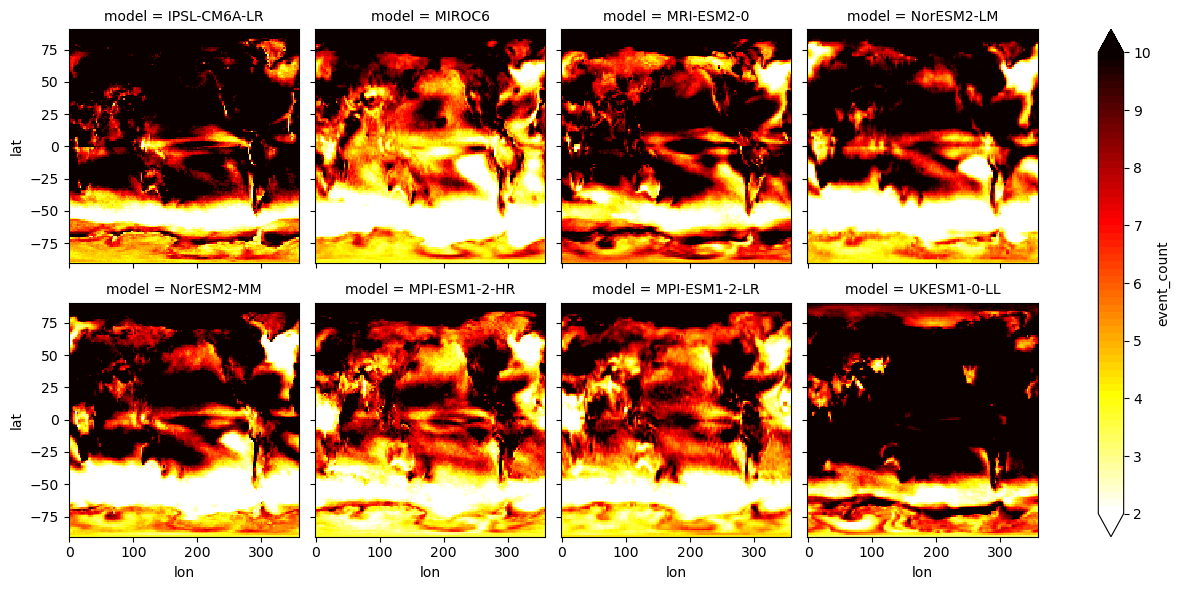

In [8]:
ds_out_regrid.event_count.plot(col='model', col_wrap=4, cmap=cmaps.matlab_hot_r, vmin=2, vmax=10)

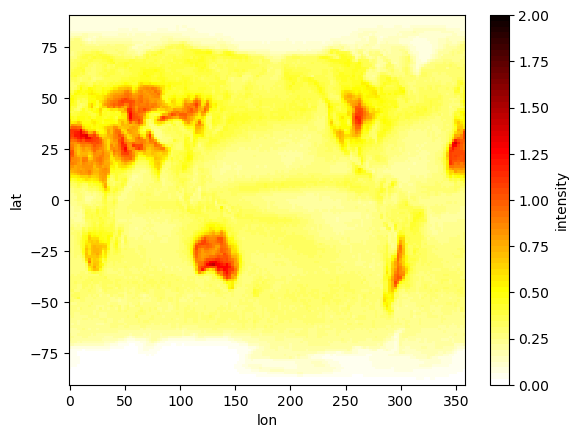

In [4]:
multi_model_mean = ds_out_regrid.mean(dim='model')

multi_model_mean.intensity.plot(cmap=cmaps.matlab_hot_r,  vmin=0, vmax=2)

In [5]:
from matplotlib.colors import LinearSegmentedColormap
cmap20 = LinearSegmentedColormap.from_list(
    "fire_fast_dark",
    [
        "#fffff0",
        "#ffef66",
        "#ffcc00",
        "#ff8800",
        "#ff3300",
        "#cc0000",
        "#770000",
        "#220000",
        "#000000",
    ],
    N=20
)

/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_62691/3907582356.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


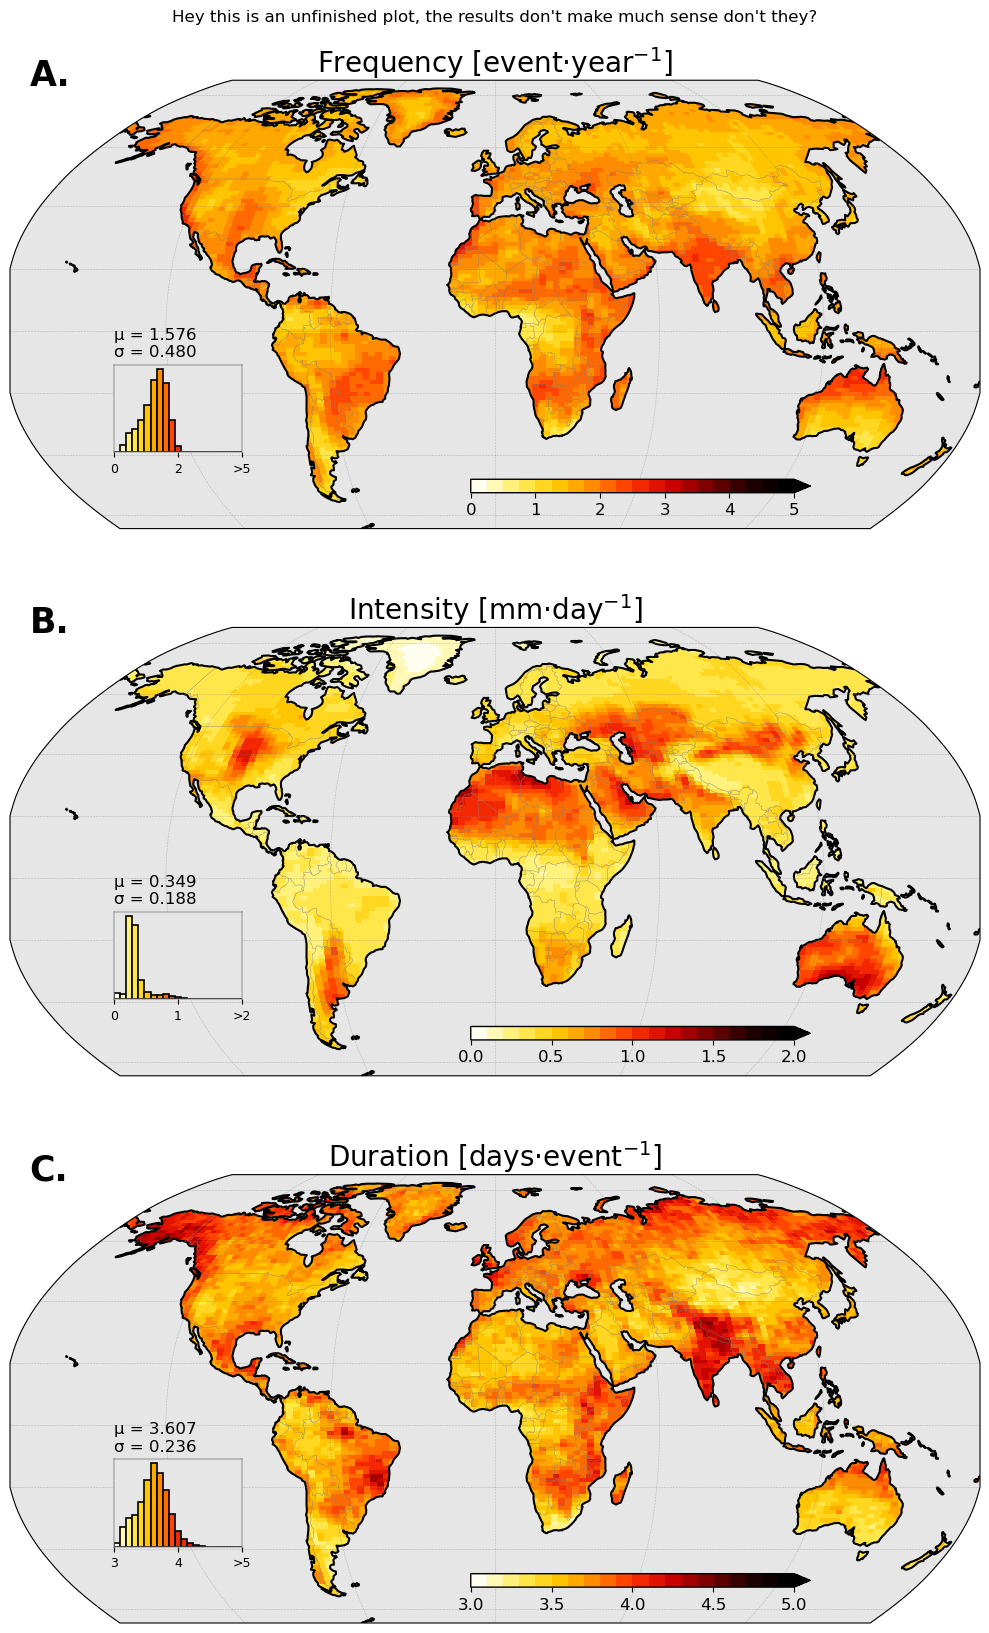

In [6]:


# ============================================================
# 4. plotting helper
# ============================================================
def plot_panel(ax, plot_grid, title, vmin, vmax, cmap, extend="max", label=""):
    LON, LAT = plot_grid.lon.values, plot_grid.lat.values
    plot_grid = plot_grid.values
    im = ax.pcolormesh(
        LON, LAT, plot_grid,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax
    )

    ax.set_extent([-180, 180, -65, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, color="0.9", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, color="gray")
    ax.coastlines(linewidth=1.5)
    ax.text(
        0.02, 1.05, label,
        transform=ax.transAxes,
        fontsize=25,
        fontweight='bold',
        va='top',
        ha='left'
    )
    # ========================================================
    # inset colorbar
    # ========================================================
    cax = inset_axes(
        ax,
        width="35%",
        height="3%",
        loc='lower center',
        bbox_to_anchor=(0.15, 0.08, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    cb = plt.colorbar(
        im,
        cax=cax,
        orientation="horizontal",
        extend=extend
    )

    cb.ax.tick_params(labelsize=12)
    cb.ax.xaxis.set_label_position('top')
    cb.ax.xaxis.set_ticks_position('bottom')
    cb.outline.set_linewidth(1)
    cb.outline.set_edgecolor("black")
    cax.patch.set_alpha(0.8)

    ax.set_title(title, fontsize=20)

    # ========================================================
    # inset histogram (area-weighted)
    # ========================================================
    if np.ndim(LAT) == 1:
        lat2d = np.repeat(LAT[:, None], plot_grid.shape[1], axis=1)
    else:
        lat2d = LAT

    weights = np.cos(np.deg2rad(lat2d))

    valid_mask = np.isfinite(plot_grid) & np.isfinite(weights)
    valid_data = plot_grid[valid_mask].flatten()
    valid_weights = weights[valid_mask].flatten()

    valid_mask = np.isfinite(plot_grid) & np.isfinite(weights)
    valid_data = plot_grid[valid_mask].flatten()
    valid_weights = weights[valid_mask].flatten()
    
    # 不要丟掉超出範圍的值，改用 clip
    global_mean = np.sum(valid_data * valid_weights) / np.sum(valid_weights)
    weighted_squared_diff = np.sum(valid_weights * (valid_data - global_mean)**2) / np.sum(valid_weights)
    global_std = np.sqrt(weighted_squared_diff)
    valid_data = np.clip(valid_data, vmin, vmax)
    if len(valid_data) > 0:
        normalized_weights = valid_weights / np.sum(valid_weights)

        inset_ax = inset_axes(
            ax,
            width="12%",
            height="15%",
            loc="lower left",
            bbox_to_anchor=(0.1, 0.155, 1.1, 1.3),
            bbox_transform=ax.transAxes
        )

        bins = np.linspace(vmin, vmax, 22)

        hist_vals, bin_edges, patches = inset_ax.hist(
            valid_data,
            bins=bins,
            weights=normalized_weights,
            density=True,
            edgecolor="black",
            linewidth=1.2
        )

        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        for patch, center in zip(patches, bin_centers):
            patch.set_facecolor(cmap(norm(center)))

        inset_ax.tick_params(labelsize=9)
        inset_ax.get_yaxis().set_visible(False)

        for spine in inset_ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
            spine.set_color("gray")
            spine.set_alpha(0.5)

        inset_ax.set_xlim(vmin, vmax)
        xticks = np.linspace(vmin, vmax, 3)  # 左、中、右
        inset_ax.set_xticks(xticks)
        formatted_mean = f"{global_mean:.3f}".replace("-", "−")
        formatted_std = f"{global_std:.3f}".replace("-", "−")
        inset_ax.set_facecolor("0.9")
        inset_ax.set_title(
            f"μ = {formatted_mean}\nσ = {formatted_std}",
            fontsize=12,
            ha="left",
            x=0
        )
        xtick_labels = [
            f"{vmin:.0f}",
            f"{xticks[1]:.0f}",
            f">{vmax:.0f}"
        ]
        inset_ax.set_xticklabels(xtick_labels)
    ax.gridlines(
        draw_labels=False,
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

    return im

# ============================================================
# 5. make 2x2 subplot
# ============================================================
fig, axes = plt.subplots(
    ncols=1, nrows=3,
    figsize=(10, 17),
    subplot_kw={"projection": ccrs.Robinson()}
)

axes = axes.flatten()

# panel A. Frequency
plot_panel(
    axes[0],
    multi_model_mean.event_count,
    r"Frequency [event·year$^{-1}$]",
    vmin=0,
    vmax=5,
    cmap=cmap20,
    extend="max", 
    label="A."
)

# panel B. Intensity
plot_panel(
    axes[1],
    multi_model_mean.intensity,
    r"Intensity [mm·day$^{-1}$]",
    vmin=0,
    vmax=2,
    cmap=cmap20,
    extend="max", 
    label="B."
)

# panel C. Duration
plot_panel(
    axes[2],
    multi_model_mean.mean_duration,
    r"Duration [days·event$^{-1}$]",
    vmin=3,
    vmax=5,
    cmap=cmap20,
    extend="max", 
    label="C."
)

# TODO: panel D. Fractional contribution of radiative term

plt.suptitle("Hey this is an unfinished plot, the results don't make much sense don't they?")

plt.tight_layout()

plt.show()